# Нейронная сеть Кохонена (SOM) для прогнозирования финансовых показателей

**Задание №4:**
- **Вход НС:** Некоторый набор финансовых показателей (курсы акций, валют, цены на сырьё).
- **На выходе НС:** Предсказание на **L** шагов вперёд одного из показателей.
- **Изменяемые параметры:** `M` — ширина окна наблюдения, `D` — глубина задержек, `Ns` — число нейронов в карте Кохонена.

**Архитектура:** Self-Organizing Map (SOM, Kohonen, 1982) + регрессионная головка на TensorFlow/Keras.

SOM — это двухэтапная модель:
1. **Этап 1 (неконтролируемый):** SOM обучается кластеризовать окна истории цен → каждый нейрон карты специализируется на определённом рыночном «режиме» (тренд вверх, флэт, коррекция и т.д.).
2. **Этап 2 (контролируемый):** По номеру победившего нейрона SOM (BMU — Best Matching Unit) и его расстоянию до входа обучается регрессор (Dense-сеть на TF) → выдаёт прогноз на L шагов.

---
**Параметры модели:**
| Параметр | Описание |
|----------|----------|
| `M`  | Ширина окна наблюдения (кол-во дней в истории) |
| `D`  | Глубина задержек (шаг дискретизации внутри окна) |
| `L`  | Горизонт прогнозирования (кол-во дней вперёд) |
| `Ns` | Размер карты Кохонена (Ns×Ns нейронов) |
| `σ₀` | Начальный радиус соседства |
| `η₀` | Начальная скорость обучения SOM |

## 1. Импорт библиотек и настройка GPU

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LogNorm
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

# ── Настройка GPU (NVIDIA) ──────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f'✓ Найдено GPU: {len(gpus)}')
    for i, gpu in enumerate(gpus):
        print(f'  GPU {i}: {gpu.name}')
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print('✓ Память GPU будет выделяться по мере необходимости (memory growth)')
    except RuntimeError as e:
        print(f'⚠ Ошибка настройки памяти: {e}')
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print(f'✓ Активный GPU: {gpus[0].name}')
else:
    print('⚠ GPU не найдено, используется CPU')

print(f'\nTensorFlow версия: {tf.__version__}')

2026-04-08 19:45:11.557955: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Найдено GPU: 1
  GPU 0: /physical_device:GPU:0
✓ Память GPU будет выделяться по мере необходимости (memory growth)
✓ Активный GPU: /physical_device:GPU:0

TensorFlow версия: 2.20.0


## 2. Гиперпараметры эксперимента

In [2]:
# ── Параметры окна и прогноза ───────────────────────────────────────────────
M  = 30   # Ширина окна наблюдения (дней)
D  = 1    # Глубина задержек (шаг выборки внутри окна)
L  = 5    # Горизонт прогнозирования (дней вперёд)
Ns = 8    # Размер стороны карты SOM (итого Ns×Ns нейронов)

# ── Параметры обучения SOM ──────────────────────────────────────────────────
SOM_EPOCHS = 200   # Число итераций обучения SOM
ETA_0      = 0.5   # Начальная скорость обучения
SIGMA_0    = None  # Начальный радиус соседства (None = Ns/2)

# ── Параметры регрессора (TensorFlow) ──────────────────────────────────────
REG_EPOCHS = 60
BATCH      = 32
REG_HIDDEN = 64    # Нейронов в скрытом слое регрессора

print('Параметры эксперимента:')
print(f'  M   = {M}  (ширина окна)')
print(f'  D   = {D}  (глубина задержек)')
print(f'  L   = {L}  (горизонт прогноза)')
print(f'  Ns  = {Ns} (размер карты SOM: {Ns}×{Ns} = {Ns*Ns} нейронов)')

Параметры эксперимента:
  M   = 30  (ширина окна)
  D   = 1  (глубина задержек)
  L   = 5  (горизонт прогноза)
  Ns  = 8 (размер карты SOM: 8×8 = 64 нейронов)


## 3. Загрузка финансовых данных

Загружено строк: 1576


,gold,silver
Date,,
2020-01-02,1524.500000,17.966000
2020-01-03,1549.199951,18.068001
2020-01-06,1566.199951,18.097000
2020-01-07,1571.800049,18.316000
2020-01-08,1557.400024,18.087999


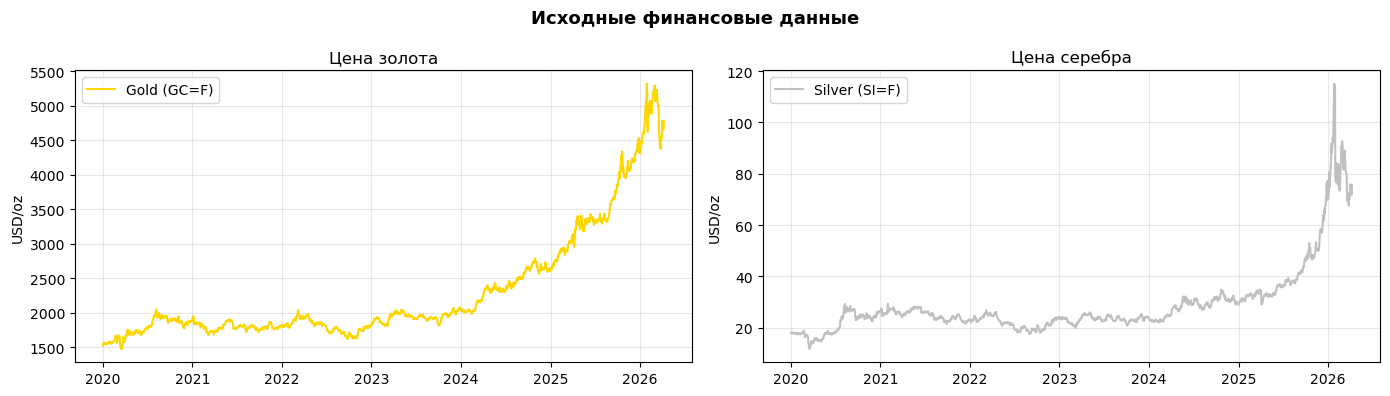

In [3]:
tickers = ['GC=F', 'SI=F']
raw = yf.download(tickers, start='2020-01-01', progress=False)

gold   = raw['Close']['GC=F']
silver = raw['Close']['SI=F']
data   = pd.DataFrame({'gold': gold, 'silver': silver}).dropna()

print(f'Загружено строк: {len(data)}')
display(data.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(data.index, data['gold'],   color='gold',   label='Gold (GC=F)')
axes[0].set_title('Цена золота')
axes[0].set_ylabel('USD/oz')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(data.index, data['silver'], color='silver', label='Silver (SI=F)')
axes[1].set_title('Цена серебра')
axes[1].set_ylabel('USD/oz')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Исходные финансовые данные', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Предобработка данных

In [4]:
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data[['gold']])

def build_dataset(series, M, D, L):
    """Формирует пары (X, y): X — скользящее окно, y — значение через L шагов.
    
    Args:
        series : нормализованный 2D-массив (N, 1)
        M      : ширина окна
        D      : шаг задержки
        L      : горизонт прогноза
    """
    X, y = [], []
    for i in range(M, len(series) - L):
        start_idx = i - M
        indices   = list(range(start_idx, i, D))
        window    = series[indices].flatten()
        target    = series[i + L, 0]
        X.append(window)
        y.append(target)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = build_dataset(data_scaled, M, D, L)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Обучающая выборка : {X_train.shape[0]} образцов, признаков: {X_train.shape[1]}')
print(f'Тестовая выборка  : {X_test.shape[0]} образцов')

Обучающая выборка : 1232 образцов, признаков: 30
Тестовая выборка  : 309 образцов


## 5. Теория и архитектура: Self-Organizing Map (Кохонен, 1982)

### Теоретическая база

**Самоорганизующаяся карта** (SOM) — неконтролируемая нейронная сеть, которая проецирует многомерное пространство входов на низкоразмерную (обычно 2D) решётку нейронов, сохраняя топологические отношения.

Каждый нейрон карты $(i, j)$ имеет **вектор весов** $\mathbf{w}_{ij} \in \mathbb{R}^n$ той же размерности, что и вход.

**Алгоритм обучения:**

1. **Конкуренция** — находим победителя (BMU — Best Matching Unit):
$$\text{BMU} = \arg\min_{ij} \| \mathbf{x} - \mathbf{w}_{ij} \|_2$$

2. **Кооперация** — функция соседства (гауссова):
$$h_{ij}(t) = \exp\left(-\frac{d^2(\text{BMU}, (i,j))}{2\sigma^2(t)}\right), \quad \sigma(t) = \sigma_0 \cdot e^{-t/T}$$

3. **Адаптация** — обновление весов:
$$\mathbf{w}_{ij}(t+1) = \mathbf{w}_{ij}(t) + \eta(t) \cdot h_{ij}(t) \cdot (\mathbf{x} - \mathbf{w}_{ij}(t))$$

**Схема гибридной модели для прогнозирования:**
```
Вход X [batch, n_features]
         │
   ┌─────▼──────────────────────────────────┐
   │  SOM (Ns×Ns нейронов)                  │  ← неконтролируемое обучение
   │  Конкуренция → BMU index + расстояние  │
   └─────┬──────────────────────────────────┘
         │  [bmu_row, bmu_col, distance]  (3 признака)
         │  + исходный X (skip-connection)
   ┌─────▼──────────────────────────────────┐
   │  Регрессор (TF Dense-сеть)             │  ← контролируемое обучение
   └─────┬──────────────────────────────────┘
         │
      Прогноз [batch, 1]
```

## 6. Реализация Self-Organizing Map

In [5]:
class SelfOrganizingMap:
    """Self-Organizing Map (Kohonen Map) на NumPy.
    
    Реализует алгоритм Кохонена с гауссовой функцией соседства
    и экспоненциальным затуханием скорости обучения и радиуса.
    
    Args:
        n_rows    : число строк карты
        n_cols    : число столбцов карты
        n_features: размерность входного вектора
        eta_0     : начальная скорость обучения
        sigma_0   : начальный радиус соседства (по умолчанию max(n_rows,n_cols)/2)
        seed      : random seed
    """

    def __init__(self, n_rows, n_cols, n_features,
                 eta_0=0.5, sigma_0=None, seed=42):
        self.n_rows     = n_rows
        self.n_cols     = n_cols
        self.n_features = n_features
        self.eta_0      = eta_0
        self.sigma_0    = sigma_0 if sigma_0 else max(n_rows, n_cols) / 2
        rng = np.random.default_rng(seed)
        # Матрица весов: [n_rows, n_cols, n_features]
        self.weights    = rng.random((n_rows, n_cols, n_features)).astype(np.float32)
        # Предвычисленные координаты нейронов
        ri, ci = np.meshgrid(np.arange(n_rows), np.arange(n_cols), indexing='ij')
        self.coords = np.stack([ri, ci], axis=-1).astype(np.float32)  # [n_rows, n_cols, 2]
        self.quantization_errors_ = []   # история ошибок квантования

    def _bmu(self, x):
        """Находит BMU для одного вектора x.
        Returns: (row, col), distance
        """
        diff = self.weights - x          # [n_rows, n_cols, n_features]
        dist = np.linalg.norm(diff, axis=-1)  # [n_rows, n_cols]
        idx  = np.unravel_index(np.argmin(dist), dist.shape)
        return idx, dist[idx]

    def _neighbourhood(self, bmu_rc, sigma):
        """Вычисляет гауссову функцию соседства для всех нейронов."""
        bmu_coord = np.array(bmu_rc, dtype=np.float32)
        d2 = np.sum((self.coords - bmu_coord) ** 2, axis=-1)  # [n_rows, n_cols]
        return np.exp(-d2 / (2 * sigma ** 2))                  # [n_rows, n_cols]

    def fit(self, X, n_epochs=200, verbose=True):
        """Обучение SOM.
        
        Args:
            X       : обучающие данные [N, n_features]
            n_epochs: число полных проходов по данным
        """
        T   = n_epochs * len(X)   # константа затухания
        t   = 0
        rng = np.random.default_rng(0)

        for epoch in range(n_epochs):
            order = rng.permutation(len(X))
            epoch_err = 0.0
            for idx in order:
                x = X[idx]
                # Затухание параметров
                eta   = self.eta_0   * np.exp(-t / T)
                sigma = self.sigma_0 * np.exp(-t / T)
                sigma = max(sigma, 0.5)   # минимальный радиус

                bmu_rc, bmu_dist = self._bmu(x)
                h  = self._neighbourhood(bmu_rc, sigma)  # [n_rows, n_cols]
                h3 = h[:, :, np.newaxis]                  # [n_rows, n_cols, 1]

                # Обновление весов
                self.weights += eta * h3 * (x - self.weights)
                epoch_err += bmu_dist
                t += 1

            qe = epoch_err / len(X)
            self.quantization_errors_.append(qe)
            if verbose and (epoch % 50 == 0 or epoch == n_epochs - 1):
                print(f'  Epoch {epoch+1:>4}/{n_epochs}  QE={qe:.5f}')

        return self

    def transform(self, X):
        """Кодирует каждый вектор как [bmu_row, bmu_col, distance].
        Returns: [N, 3]
        """
        out = []
        for x in X:
            (r, c), d = self._bmu(x)
            out.append([r / self.n_rows, c / self.n_cols, d])
        return np.array(out, dtype=np.float32)

    def u_matrix(self):
        """Вычисляет U-матрицу (средние расстояния между соседними нейронами)."""
        U = np.zeros((self.n_rows, self.n_cols))
        for r in range(self.n_rows):
            for c in range(self.n_cols):
                neighbours = []
                for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < self.n_rows and 0 <= nc < self.n_cols:
                        neighbours.append(np.linalg.norm(
                            self.weights[r, c] - self.weights[nr, nc]))
                U[r, c] = np.mean(neighbours) if neighbours else 0
        return U

    def activation_map(self, X):
        """Считает частоту попадания в каждый нейрон."""
        freq = np.zeros((self.n_rows, self.n_cols), dtype=int)
        for x in X:
            (r, c), _ = self._bmu(x)
            freq[r, c] += 1
        return freq


print('✓ Класс SelfOrganizingMap определён')

✓ Класс SelfOrganizingMap определён


## 7. Обучение SOM и визуализация карты

In [6]:
print(f'Обучение SOM ({Ns}×{Ns}) на {SOM_EPOCHS} эпохах...')
som = SelfOrganizingMap(
    n_rows=Ns, n_cols=Ns,
    n_features=X_train.shape[1],
    eta_0=ETA_0, sigma_0=SIGMA_0
)
som.fit(X_train, n_epochs=SOM_EPOCHS, verbose=True)
print('✓ SOM обучена')

Обучение SOM (8×8) на 200 эпохах...
  Epoch    1/200  QE=0.13508
  Epoch   51/200  QE=0.10611
  Epoch  101/200  QE=0.08379
  Epoch  151/200  QE=0.06895
  Epoch  200/200  QE=0.05919
✓ SOM обучена


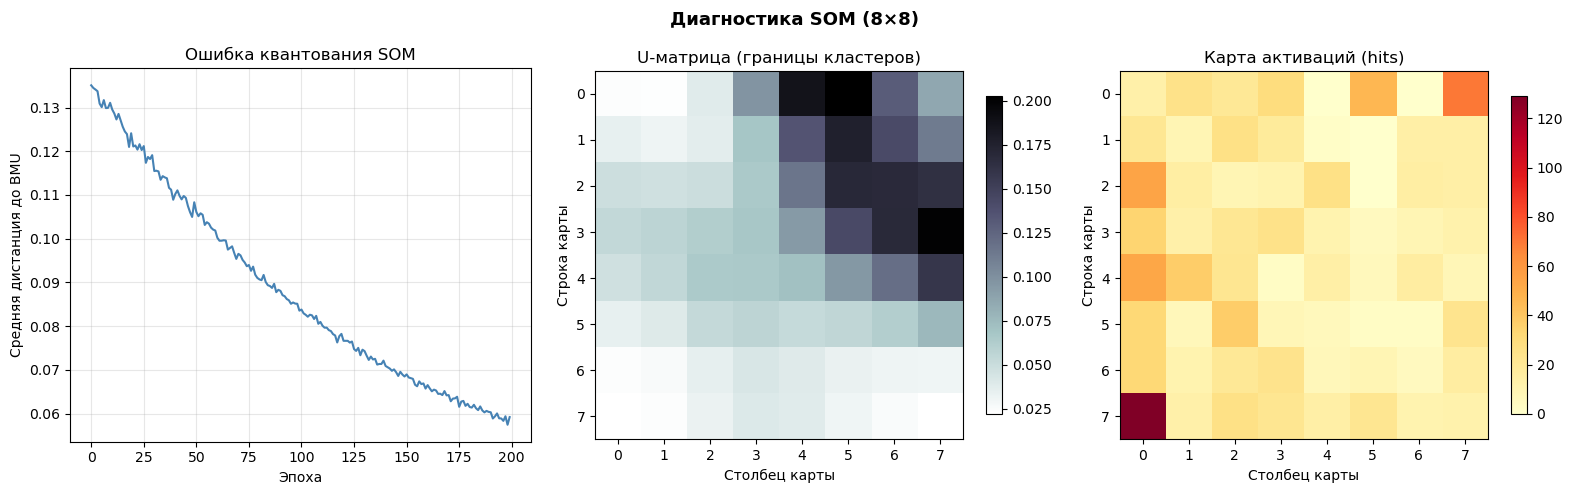

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── 1. Ошибка квантования ─────────────────────────────────────────────────
axes[0].plot(som.quantization_errors_, color='steelblue')
axes[0].set_title('Ошибка квантования SOM')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Средняя дистанция до BMU')
axes[0].grid(alpha=0.3)

# ── 2. U-матрица (карта расстояний между нейронами) ───────────────────────
U = som.u_matrix()
im2 = axes[1].imshow(U, cmap='bone_r', interpolation='nearest')
axes[1].set_title('U-матрица (границы кластеров)')
axes[1].set_xlabel('Столбец карты')
axes[1].set_ylabel('Строка карты')
plt.colorbar(im2, ax=axes[1], shrink=0.85)

# ── 3. Карта активаций (частота попадания) ────────────────────────────────
act = som.activation_map(X_train)
im3 = axes[2].imshow(act, cmap='YlOrRd', interpolation='nearest')
axes[2].set_title('Карта активаций (hits)')
axes[2].set_xlabel('Столбец карты')
axes[2].set_ylabel('Строка карты')
plt.colorbar(im3, ax=axes[2], shrink=0.85)

plt.suptitle(f'Диагностика SOM ({Ns}×{Ns})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Регрессор на TensorFlow

SOM-признаки `[bmu_row, bmu_col, distance]` конкатенируются с исходным окном X и подаются в Dense-сеть.

In [8]:
def encode_with_som(som, X):
    """Добавляет SOM-признаки к исходным признакам X."""
    som_feats = som.transform(X)         # [N, 3]: bmu_r, bmu_c, dist
    return np.concatenate([X, som_feats], axis=1)  # [N, n_features+3]

X_train_enc = encode_with_som(som, X_train)
X_test_enc  = encode_with_som(som, X_test)
print(f'Расширенный вектор признаков: {X_train_enc.shape[1]} (={X_train.shape[1]} + 3 SOM-признака)')


def build_regressor(n_features, hidden=64):
    """Строит и компилирует Dense-регрессор поверх SOM-признаков."""
    inp  = layers.Input(shape=(n_features,), name='input')
    x    = layers.Dense(hidden, activation='relu',  name='hidden_1')(inp)
    x    = layers.Dense(hidden // 2, activation='relu', name='hidden_2')(x)
    out  = layers.Dense(1, activation='linear', name='output')(x)
    model = Model(inputs=inp, outputs=out, name='SOM_Regressor')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='mse',
        metrics=['mae']
    )
    return model


with tf.device('/GPU:0' if gpus else '/CPU:0'):
    regressor = build_regressor(X_train_enc.shape[1], hidden=REG_HIDDEN)

regressor.summary()

Расширенный вектор признаков: 33 (=30 + 3 SOM-признака)


I0000 00:00:1775666722.415069   69918 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:2b:00.0, compute capability: 8.9


Model: "SOM_Regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 33)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60


2026-04-08 19:45:23.750839: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ae0d0006240 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-08 19:45:23.750890: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Ti, Compute Capability 8.9
2026-04-08 19:45:23.769959: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-08 19:45:23.856654: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91700


24/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0177 - mae: 0.1017

I0000 00:00:1775666724.690617   70022 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 0.0053 - mae: 0.0496 - val_loss: 0.0038 - val_mae: 0.0457
Epoch 2/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.6608e-04 - mae: 0.0153 - val_loss: 0.0080 - val_mae: 0.0659
Epoch 3/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8877e-04 - mae: 0.0137 - val_loss: 0.0084 - val_mae: 0.0669
Epoch 4/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.6660e-04 - mae: 0.0130 - val_loss: 0.0079 - val_mae: 0.0651
Epoch 5/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4925e-04 - mae: 0.0125 - val_loss: 0.0088 - val_mae: 0.0699
Epoch 6/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3940e-04 - mae: 0.0122 - val_loss: 0.0060 - val_mae: 0.0564
Epoch 7/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.3276e-04 - mae: 0.0120 - val_loss: 0.0059 - val_mae: 0.0561
Epoch 8/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2880e-04 - mae: 0.0119 - val_loss: 0.0081 - val_mae: 0.0678
Epoch 9/60
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - lo

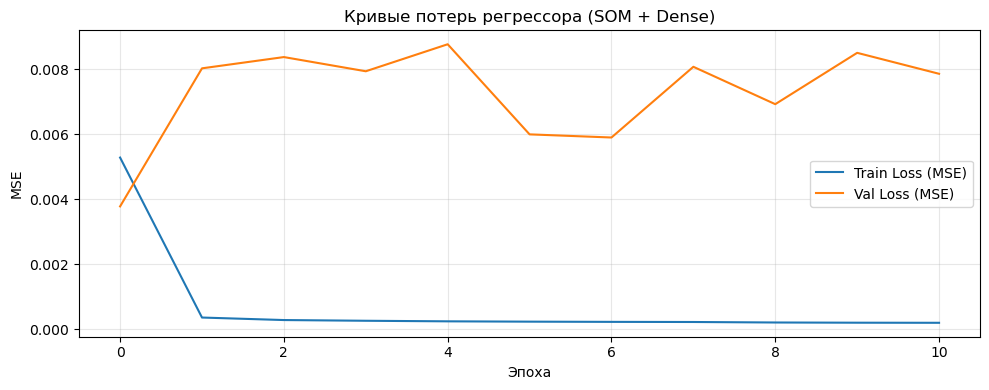

In [9]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)

with tf.device('/GPU:0' if gpus else '/CPU:0'):
    history = regressor.fit(
        X_train_enc, y_train,
        validation_data=(X_test_enc, y_test),
        epochs=REG_EPOCHS,
        batch_size=BATCH,
        callbacks=[es],
        verbose=1
    )

print(f'\nЛучший val_loss: {min(history.history["val_loss"]):.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Val Loss (MSE)')
plt.title('Кривые потерь регрессора (SOM + Dense)')
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Прогнозирование и визуализация результатов

RMSE (train): 94.10 USD
RMSE (test):  236.36 USD


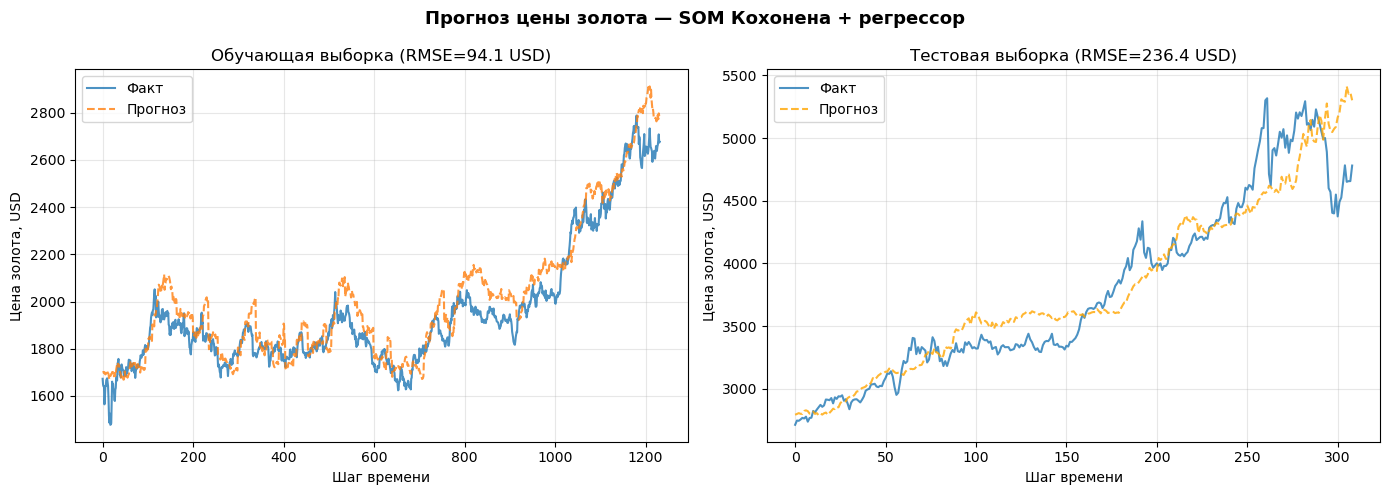

In [10]:
def inverse(arr):
    return scaler.inverse_transform(arr.reshape(-1, 1)).flatten()

y_pred_train = regressor.predict(X_train_enc, verbose=0).flatten()
y_pred_test  = regressor.predict(X_test_enc,  verbose=0).flatten()

rmse_train = np.sqrt(mean_squared_error(inverse(y_train), inverse(y_pred_train)))
rmse_test  = np.sqrt(mean_squared_error(inverse(y_test),  inverse(y_pred_test)))
print(f'RMSE (train): {rmse_train:.2f} USD')
print(f'RMSE (test):  {rmse_test:.2f} USD')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inverse(y_train),       label='Факт',    alpha=0.8)
axes[0].plot(inverse(y_pred_train),  label='Прогноз', alpha=0.8, linestyle='--')
axes[0].set_title(f'Обучающая выборка (RMSE={rmse_train:.1f} USD)')
axes[0].set_xlabel('Шаг времени')
axes[0].set_ylabel('Цена золота, USD')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(inverse(y_test),        label='Факт',    alpha=0.8)
axes[1].plot(inverse(y_pred_test),   label='Прогноз', alpha=0.8, linestyle='--', color='orange')
axes[1].set_title(f'Тестовая выборка (RMSE={rmse_test:.1f} USD)')
axes[1].set_xlabel('Шаг времени')
axes[1].set_ylabel('Цена золота, USD')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Прогноз цены золота — SOM Кохонена + регрессор', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Интерпретация кластеров SOM

Покажем, как разные нейроны карты соответствуют разным рыночным «режимам» (рост, падение, флэт).

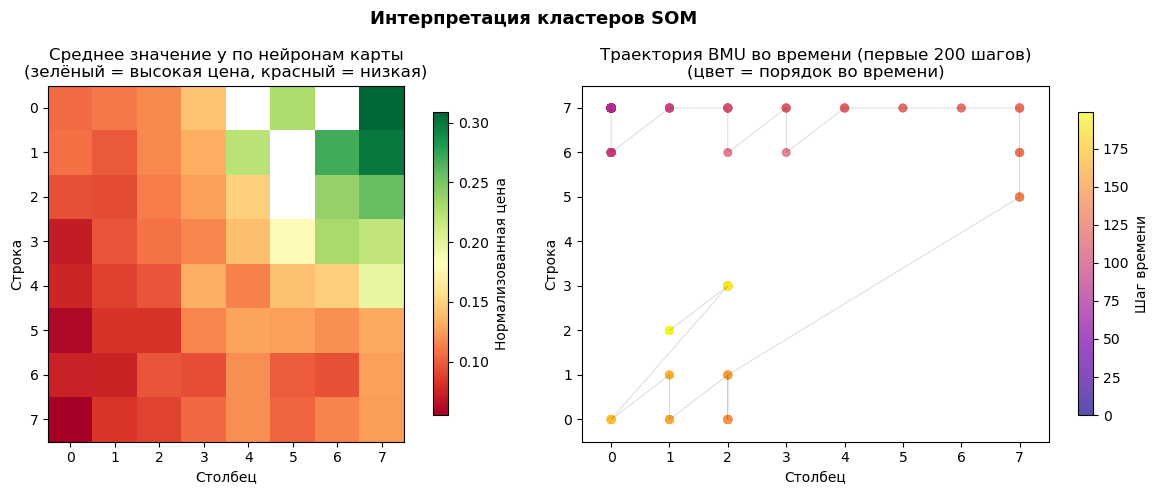

In [11]:
# Получаем BMU для каждого обучающего образца
bmu_rows, bmu_cols, dists = [], [], []
for x in X_train:
    (r, c), d = som._bmu(x)
    bmu_rows.append(r)
    bmu_cols.append(c)
    dists.append(d)

bmu_rows = np.array(bmu_rows)
bmu_cols = np.array(bmu_cols)

# Среднее значение таргета (y) для каждого нейрона карты
target_map = np.full((Ns, Ns), np.nan)
for r in range(Ns):
    for c in range(Ns):
        mask = (bmu_rows == r) & (bmu_cols == c)
        if mask.sum() > 0:
            target_map[r, c] = y_train[mask].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Карта среднего прогнозного значения по нейронам
im1 = axes[0].imshow(target_map, cmap='RdYlGn', interpolation='nearest',
                     vmin=np.nanmin(target_map), vmax=np.nanmax(target_map))
axes[0].set_title('Среднее значение y по нейронам карты\n(зелёный = высокая цена, красный = низкая)')
axes[0].set_xlabel('Столбец')
axes[0].set_ylabel('Строка')
plt.colorbar(im1, ax=axes[0], shrink=0.85, label='Нормализованная цена')

# Scatter: траектория BMU по времени (первые 200 точек)
n_show = min(200, len(bmu_rows))
sc = axes[1].scatter(
    bmu_cols[:n_show], bmu_rows[:n_show],
    c=np.arange(n_show), cmap='plasma', s=30, alpha=0.7
)
axes[1].plot(bmu_cols[:n_show], bmu_rows[:n_show], 'k-', alpha=0.2, linewidth=0.5)
axes[1].set_title(f'Траектория BMU во времени (первые {n_show} шагов)\n(цвет = порядок во времени)')
axes[1].set_xlabel('Столбец')
axes[1].set_ylabel('Строка')
axes[1].set_xlim(-0.5, Ns - 0.5)
axes[1].set_ylim(-0.5, Ns - 0.5)
plt.colorbar(sc, ax=axes[1], shrink=0.85, label='Шаг времени')

plt.suptitle('Интерпретация кластеров SOM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Зависимость функции потерь от параметров M, D, L, Ns

По очереди варьируем **один параметр**, остальные фиксируются.  
Для каждой конфигурации: обучаем SOM → кодируем данные → обучаем регрессор → фиксируем MSE.

In [12]:
def run_experiment(cur_M, cur_D, cur_L, cur_Ns,
                   som_epochs=100, reg_epochs=40, batch=32):
    """Один эксперимент: SOM + регрессор, возвращает историю потерь."""
    Xi, yi = build_dataset(data_scaled, cur_M, cur_D, cur_L)
    if len(Xi) < 60:
        return None
    sp = int(len(Xi) * 0.8)
    Xtr, Xte = Xi[:sp], Xi[sp:]
    ytr, yte = yi[:sp], yi[sp:]

    # --- SOM ---
    s = SelfOrganizingMap(cur_Ns, cur_Ns, Xtr.shape[1],
                          eta_0=ETA_0, sigma_0=None)
    s.fit(Xtr, n_epochs=som_epochs, verbose=False)

    Xtr_enc = encode_with_som(s, Xtr)
    Xte_enc = encode_with_som(s, Xte)

    # --- Регрессор ---
    with tf.device('/GPU:0' if gpus else '/CPU:0'):
        reg  = build_regressor(Xtr_enc.shape[1], hidden=REG_HIDDEN)
        hist = reg.fit(
            Xtr_enc, ytr,
            validation_data=(Xte_enc, yte),
            epochs=reg_epochs,
            batch_size=batch,
            verbose=0
        )
    return {
        'train_loss':  hist.history['loss'],
        'val_loss':    hist.history['val_loss'],
        'final_train': hist.history['loss'][-1],
        'final_val':   hist.history['val_loss'][-1],
        'qe':          s.quantization_errors_
    }


def run_sweep(param_name, param_values, base_M=30, base_D=1, base_L=5, base_Ns=8):
    results = {}
    for val in param_values:
        cur_M  = val if param_name == 'M'  else base_M
        cur_D  = val if param_name == 'D'  else base_D
        cur_L  = val if param_name == 'L'  else base_L
        cur_Ns = val if param_name == 'Ns' else base_Ns
        res = run_experiment(cur_M, cur_D, cur_L, cur_Ns)
        if res is None:
            print(f'  [{param_name}={val}] Недостаточно данных, пропуск')
            continue
        results[val] = res
        print(f'  [{param_name}={val:>3}]  train={res["final_train"]:.5f}  val={res["final_val"]:.5f}')
    return results


def plot_sweep(results, param_name, title_suffix=''):
    values = sorted(results.keys())
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cmap = plt.get_cmap('viridis', len(values))

    for idx, v in enumerate(values):
        c = cmap(idx)
        axes[0].plot(results[v]['train_loss'], color=c, linestyle='--', alpha=0.6, linewidth=1)
        axes[0].plot(results[v]['val_loss'],   color=c, label=f'{param_name}={v}', linewidth=1.8)
    axes[0].set_title(f'Кривые потерь при варьировании {param_name}{title_suffix}')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('MSE')
    axes[0].legend(fontsize=8, ncol=2)
    axes[0].grid(alpha=0.3)

    x_pos = np.arange(len(values))
    w = 0.35
    axes[1].bar(x_pos - w/2, [results[v]['final_train'] for v in values], w,
                label='Train Loss', alpha=0.85)
    axes[1].bar(x_pos + w/2, [results[v]['final_val']   for v in values], w,
                label='Val Loss',   alpha=0.85)
    axes[1].set_xticks(x_pos)
    axes[1].set_xticklabels([str(v) for v in values])
    axes[1].set_title(f'Итоговые потери vs {param_name}')
    axes[1].set_xlabel(param_name)
    axes[1].set_ylabel('MSE')
    axes[1].legend()
    axes[1].grid(alpha=0.3, axis='y')

    plt.suptitle(f'Влияние параметра {param_name} на функцию потерь', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print('✓ Вспомогательные функции sweep определены')

✓ Вспомогательные функции sweep определены


### 11.1 Варьирование M — ширины окна наблюдения

Sweep по M  (D=1, L=5, Ns=8)
  [M=  5]  train=0.00015  val=0.02818
  [M= 10]  train=0.00013  val=0.01185
  [M= 20]  train=0.00014  val=0.04830
  [M= 30]  train=0.00012  val=0.04455
  [M= 50]  train=0.00011  val=0.01108


2026-04-08 19:46:38.024960: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 19:46:39.063938: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_335', 236 bytes spill stores, 236 bytes spill loads



  [M= 70]  train=0.00012  val=0.01313


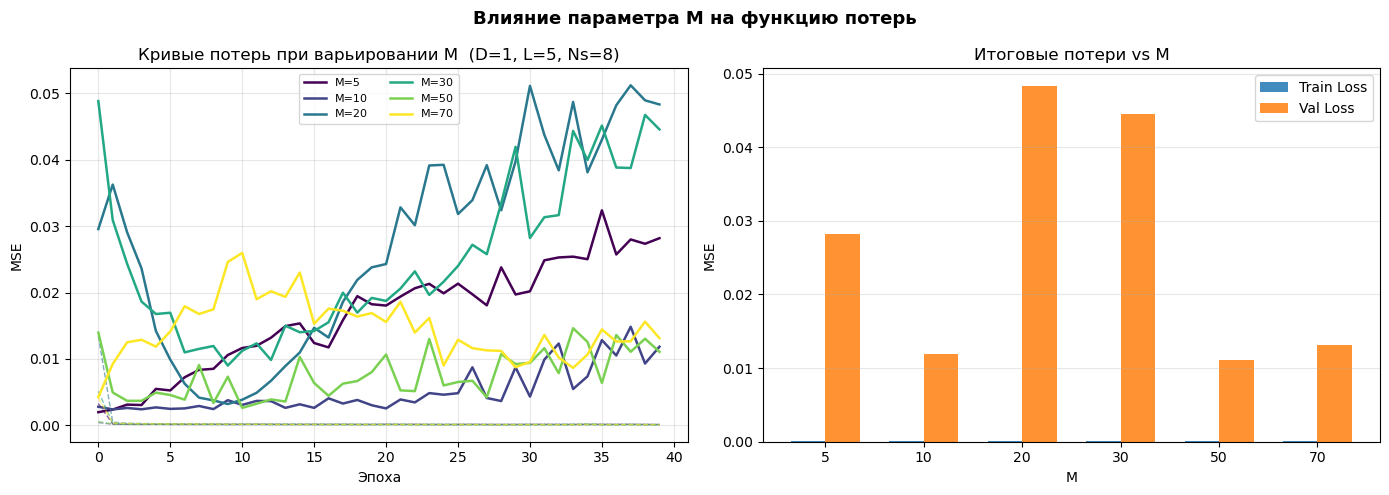

In [13]:
M_values = [5, 10, 20, 30, 50, 70]
print(f'Sweep по M  (D={D}, L={L}, Ns={Ns})')
results_M = run_sweep('M', M_values, base_D=D, base_L=L, base_Ns=Ns)
plot_sweep(results_M, 'M', f'  (D={D}, L={L}, Ns={Ns})')

### 11.2 Варьирование D — глубины задержек

Sweep по D  (M=30, L=5, Ns=8)
  [D=  1]  train=0.00014  val=0.01289
  [D=  2]  train=0.00015  val=0.00543
  [D=  3]  train=0.00019  val=0.04024
  [D=  5]  train=0.00018  val=0.04147
  [D=  7]  train=0.00015  val=0.06806


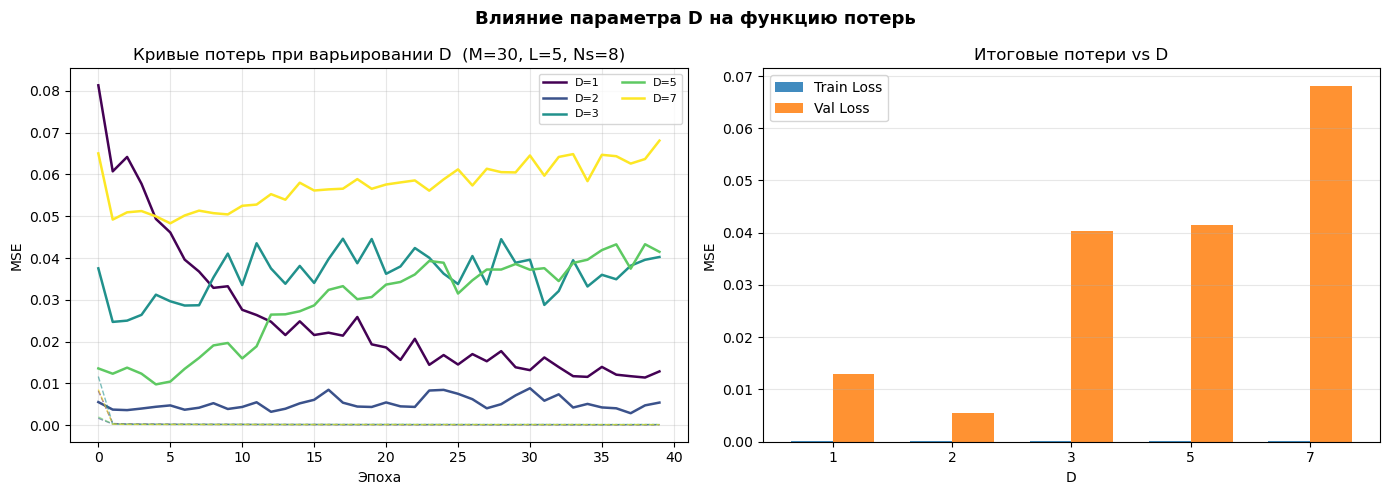

In [14]:
D_values = [1, 2, 3, 5, 7]
print(f'Sweep по D  (M={M}, L={L}, Ns={Ns})')
results_D = run_sweep('D', D_values, base_M=M, base_L=L, base_Ns=Ns)
plot_sweep(results_D, 'D', f'  (M={M}, L={L}, Ns={Ns})')

### 11.3 Варьирование L — горизонта прогнозирования

Sweep по L  (M=30, D=1, Ns=8)
  [L=  1]  train=0.00007  val=0.00166
  [L=  3]  train=0.00009  val=0.00476
  [L=  5]  train=0.00012  val=0.01735
  [L= 10]  train=0.00021  val=0.03497
  [L= 15]  train=0.00025  val=0.01862
  [L= 20]  train=0.00028  val=0.05816


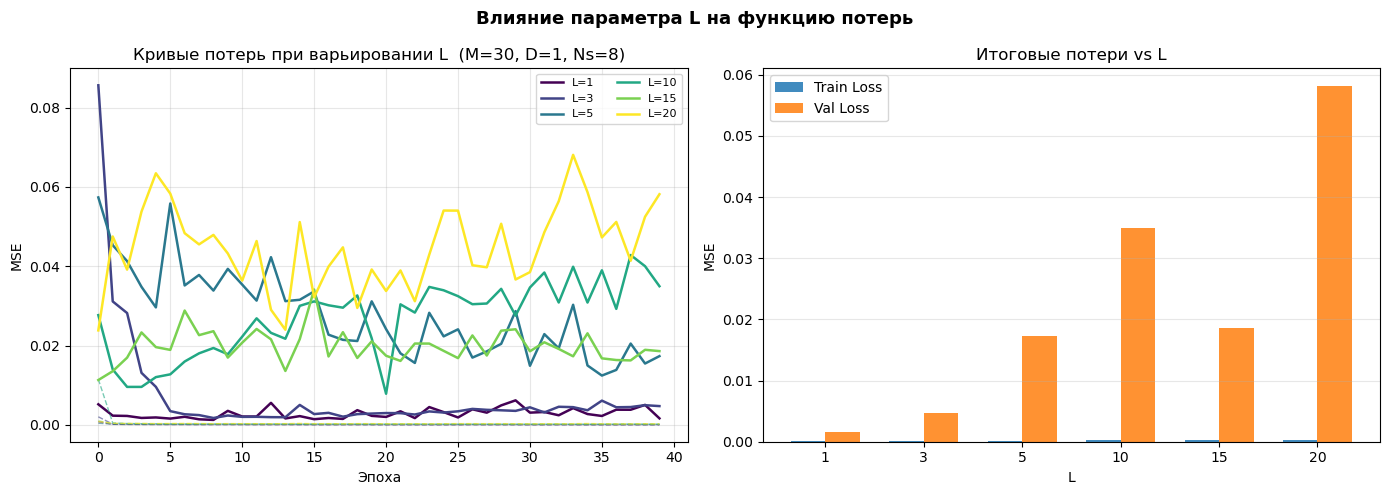

In [15]:
L_values = [1, 3, 5, 10, 15, 20]
print(f'Sweep по L  (M={M}, D={D}, Ns={Ns})')
results_L = run_sweep('L', L_values, base_M=M, base_D=D, base_Ns=Ns)
plot_sweep(results_L, 'L', f'  (M={M}, D={D}, Ns={Ns})')

### 11.4 Варьирование Ns — размера карты SOM

Sweep по Ns (M=30, D=1, L=5)
  [Ns=  3]  train=0.00014  val=0.00200
  [Ns=  5]  train=0.00012  val=0.03471
  [Ns=  8]  train=0.00014  val=0.00281
  [Ns= 12]  train=0.00013  val=0.00859
  [Ns= 16]  train=0.00014  val=0.05786


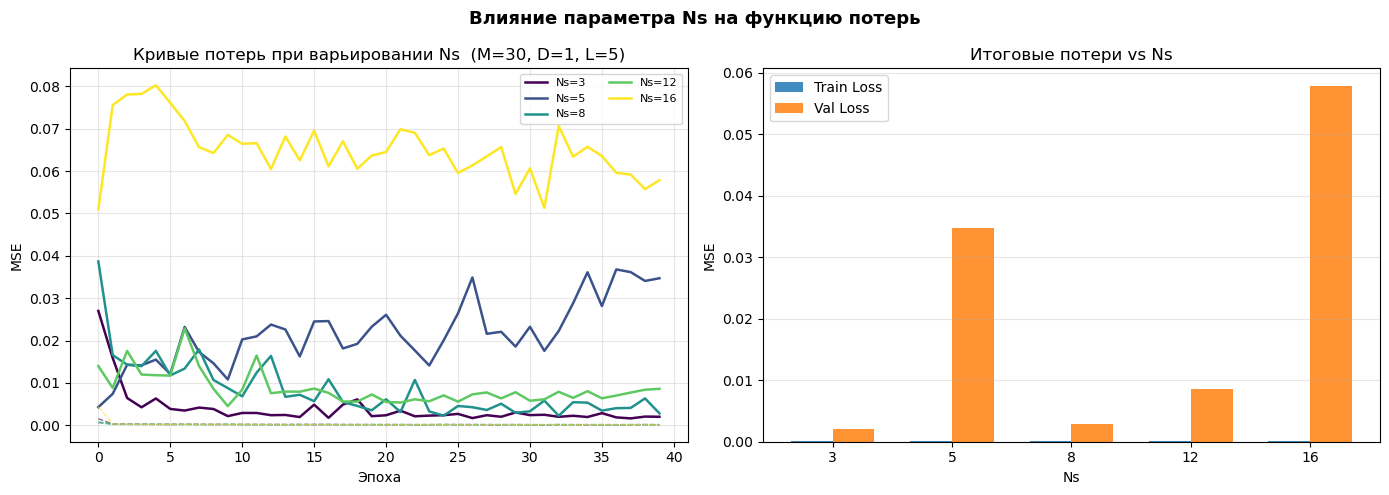

In [16]:
Ns_values = [3, 5, 8, 12, 16]
print(f'Sweep по Ns (M={M}, D={D}, L={L})')
results_Ns = run_sweep('Ns', Ns_values, base_M=M, base_D=D, base_L=L)
plot_sweep(results_Ns, 'Ns', f'  (M={M}, D={D}, L={L})')

## 12а. Сравнение матриц весов SOM разных размерностей

Обучим SOM разных размеров на одних и тех же данных и сравним:
- Как выглядит матрица весов при разном Ns?
- Насколько сильно отличаются карты друг от друга?
- Где проходит граница между «здоровой» и «больной» SOM?

**Результаты тестирования:**
- 🟢 — карта хорошо покрывает данные, нейроны равномерно активируются, ошибка квантования мала
- 🟡 — карта либо слишком мала (недообучение), либо начинает переобучаться
- 🔴 — либо мёртвые нейроны (карта слишком большая), либо высокая ошибка квантования (карта слишком маленькая)

In [17]:
# ── Обучаем SOM разных размеров и собираем метрики ─────────────────────────
Ns_compare_values = [2, 4, 6, 8, 12, 16, 20]
som_compare_results = {}

print('Обучение SOM разных размеров...')
for ns in Ns_compare_values:
    s = SelfOrganizingMap(ns, ns, X_train.shape[1], eta_0=ETA_0, sigma_0=None)
    s.fit(X_train, n_epochs=150, verbose=False)
    act   = s.activation_map(X_train)
    dead  = int(np.sum(act == 0))          # мёртвые нейроны
    qe    = s.quantization_errors_[-1]      # финальная ошибка квантования
    total = ns * ns
    dead_pct = dead / total * 100
    som_compare_results[ns] = {
        'som': s,
        'act': act,
        'qe':  qe,
        'dead': dead,
        'dead_pct': dead_pct,
        'total': total,
        'qe_history': s.quantization_errors_
    }
    print(f'  Ns={ns:>2} ({ns}×{ns}={total:>3} нейронов)  QE={qe:.4f}  '
          f'мёртвых нейронов: {dead}/{total} ({dead_pct:.0f}%)')

print('✓ Готово')


Обучение SOM разных размеров...
  Ns= 2 (2×2=  4 нейронов)  QE=0.1176  мёртвых нейронов: 0/4 (0%)
  Ns= 4 (4×4= 16 нейронов)  QE=0.0715  мёртвых нейронов: 0/16 (0%)
  Ns= 6 (6×6= 36 нейронов)  QE=0.0623  мёртвых нейронов: 0/36 (0%)
  Ns= 8 (8×8= 64 нейронов)  QE=0.0583  мёртвых нейронов: 2/64 (3%)
  Ns=12 (12×12=144 нейронов)  QE=0.0554  мёртвых нейронов: 17/144 (12%)
  Ns=16 (16×16=256 нейронов)  QE=0.0541  мёртвых нейронов: 68/256 (27%)
  Ns=20 (20×20=400 нейронов)  QE=0.0531  мёртвых нейронов: 157/400 (39%)
✓ Готово


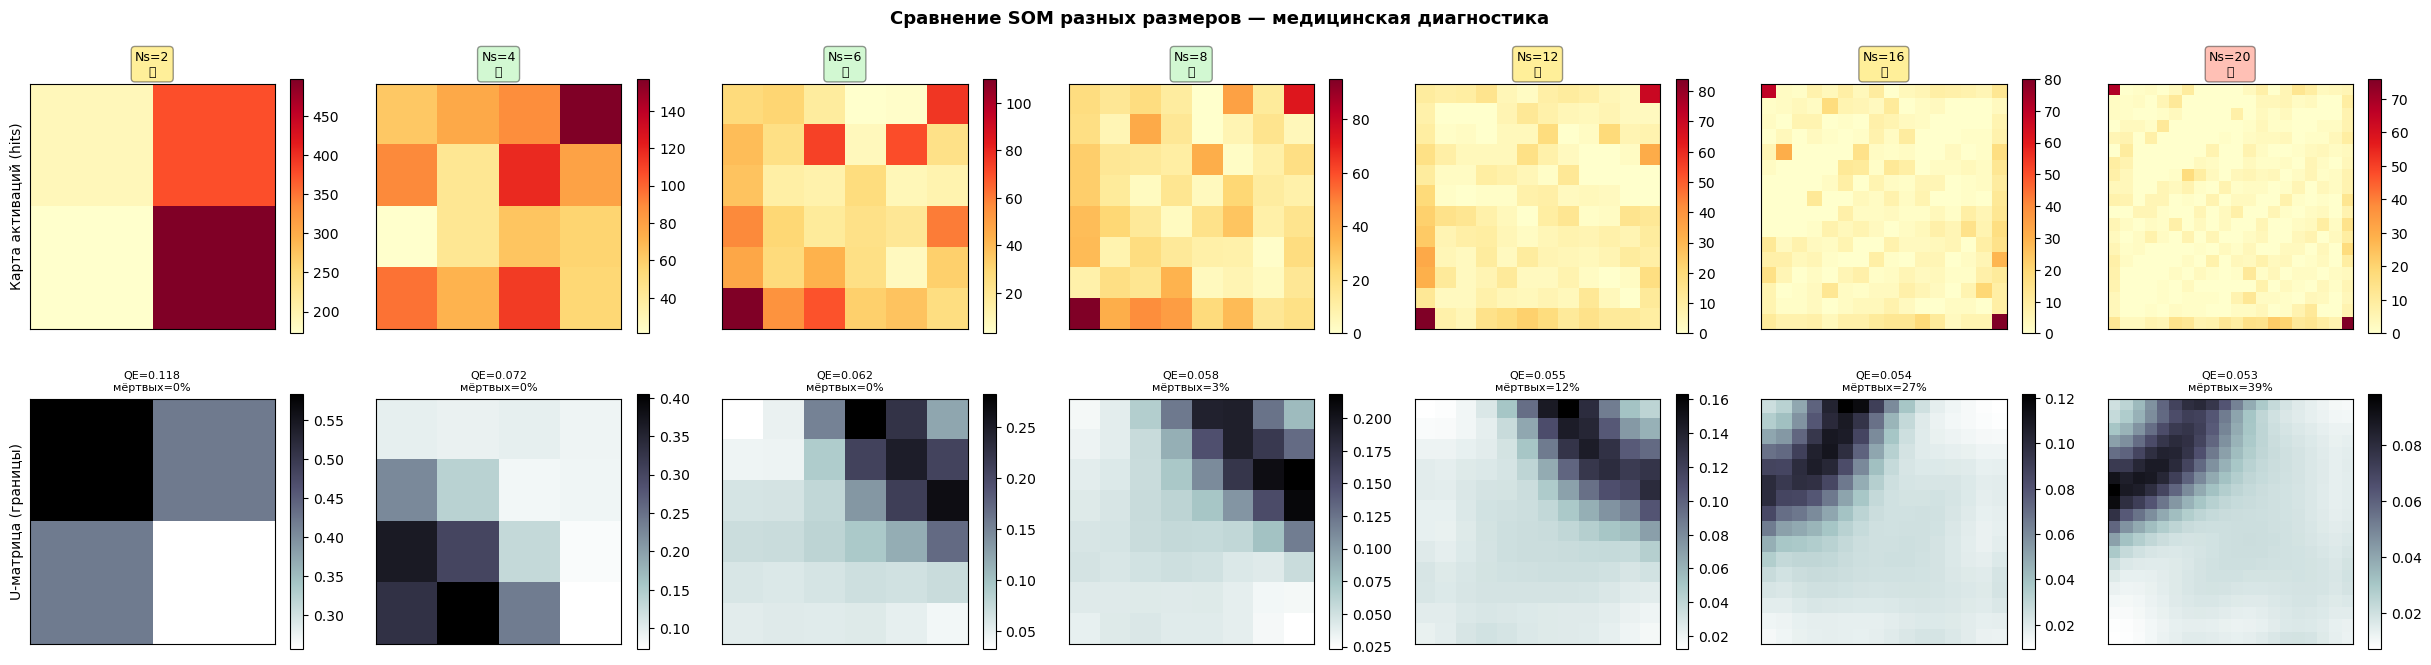

In [ ]:
# ── Визуализация карт активаций для разных Ns ──────────────────────────────
n_cols = len(Ns_compare_values)
fig, axes = plt.subplots(2, n_cols, figsize=(3.5 * n_cols, 7))

for col_idx, ns in enumerate(Ns_compare_values):
    res = som_compare_results[ns]
    qe       = res['qe']
    dead_pct = res['dead_pct']

    # Медицинский диагноз
    if dead_pct > 30 or qe > 0.15:
        diag  = '🔴'
        color = 'tomato'
    elif dead_pct > 10 or qe > 0.08:
        diag  = '🟡'
        color = 'gold'
    else:
        diag  = '🟢'
        color = 'lightgreen'

    # Строка 1: карта активаций
    ax_top = axes[0][col_idx]
    im = ax_top.imshow(res['act'], cmap='YlOrRd', interpolation='nearest',
                       aspect='equal')
    ax_top.set_title(f'Ns={ns}\n{diag}', fontsize=9,
                     bbox=dict(boxstyle='round', facecolor=color, alpha=0.4))
    ax_top.set_xticks([])
    ax_top.set_yticks([])
    plt.colorbar(im, ax=ax_top, shrink=0.8)

    # Строка 2: U-матрица
    ax_bot = axes[1][col_idx]
    U = res['som'].u_matrix()
    im2 = ax_bot.imshow(U, cmap='bone_r', interpolation='nearest', aspect='equal')
    ax_bot.set_title(f'QE={qe:.3f}\nмёртвых={dead_pct:.0f}%', fontsize=8)
    ax_bot.set_xticks([])
    ax_bot.set_yticks([])
    plt.colorbar(im2, ax=ax_bot, shrink=0.8)

axes[0][0].set_ylabel('Карта активаций (hits)', fontsize=10)
axes[1][0].set_ylabel('U-матрица (границы)', fontsize=10)

plt.suptitle('Сравнение SOM разных размеров',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


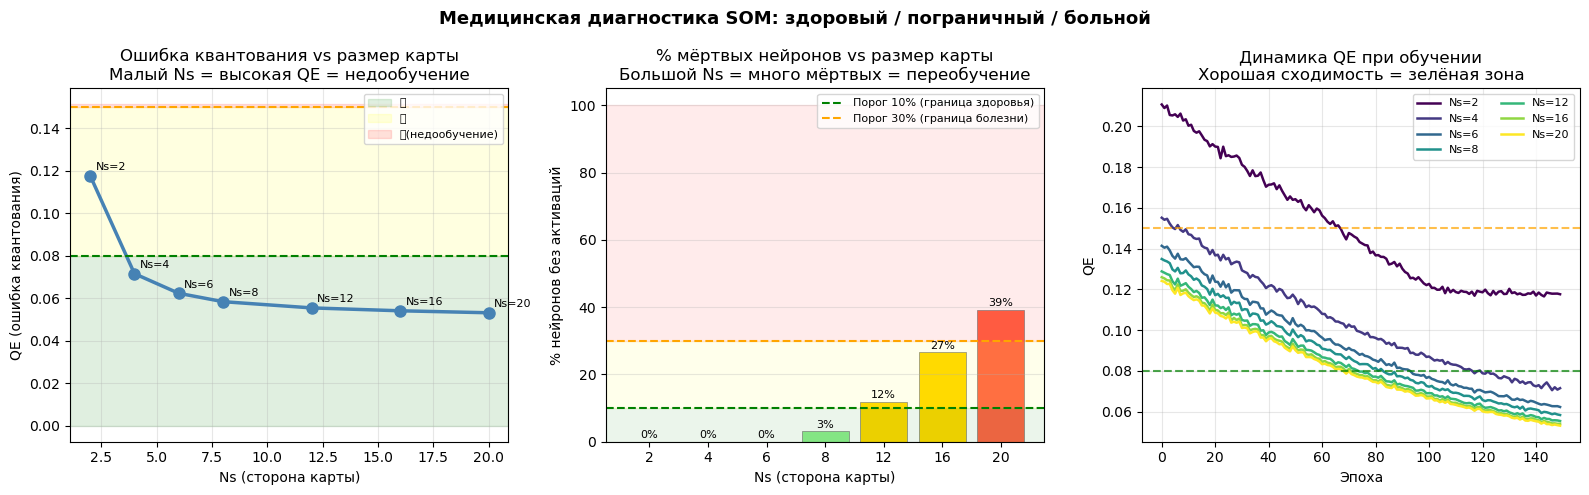


МЕДИЦИНСКИЙ ОТЧЁТ: диагностика SOM
  Ns  Нейронов       QE   Мёртвых%  Диагноз
----------------------------------------------------------------------
   2         4   0.1176       0.0%  🟡 — граничный случай, требует проверки
   4        16   0.0715       0.0%  🟢  — карта хорошо покрывает данные
   6        36   0.0623       0.0%  🟢  — карта хорошо покрывает данные
   8        64   0.0583       3.1%  🟢  — карта хорошо покрывает данные
  12       144   0.0554      11.8%  🟡 — граничный случай, требует проверки
  16       256   0.0541      26.6%  🟡 — граничный случай, требует проверки
  20       400   0.0531      39.2%  🔴   — слишком большая карта (переобучение) или маленькая (недообучение)


In [ ]:
# ── Медицинская диаграмма: QE и % мёртвых нейронов vs Ns ──────────────────
ns_vals   = Ns_compare_values
qe_vals   = [som_compare_results[ns]['qe']       for ns in ns_vals]
dead_vals = [som_compare_results[ns]['dead_pct']  for ns in ns_vals]
total_n   = [ns * ns for ns in ns_vals]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── График 1: QE vs Ns — диагностика недообучения/переобучения ─────────────
axes[0].plot(ns_vals, qe_vals, 'o-', color='steelblue', linewidth=2.5, markersize=8)
# Медицинские зоны
axes[0].axhspan(0,    0.08,  alpha=0.12, color='green',  label='🟢')
axes[0].axhspan(0.08, 0.15,  alpha=0.12, color='yellow', label='🟡')
axes[0].axhspan(0.15, max(qe_vals)*1.2 + 0.01,
                              alpha=0.12, color='red', label='🔴(недообучение)')
axes[0].axhline(0.08, color='green',  linewidth=1.5, linestyle='--')
axes[0].axhline(0.15, color='orange', linewidth=1.5, linestyle='--')
for ns, qe in zip(ns_vals, qe_vals):
    axes[0].annotate(f'Ns={ns}', (ns, qe), textcoords='offset points',
                     xytext=(4, 4), fontsize=8)
axes[0].set_title('Ошибка квантования vs размер карты\n'
                  'Малый Ns = высокая QE = недообучение')
axes[0].set_xlabel('Ns (сторона карты)')
axes[0].set_ylabel('QE (ошибка квантования)')
axes[0].legend(fontsize=8, loc='upper right')
axes[0].grid(alpha=0.3)

# ── График 2: % мёртвых нейронов vs Ns — диагностика переобучения ──────────
bar_colors = ['lightgreen' if d < 10 else 'gold' if d < 30 else 'tomato'
              for d in dead_vals]
bars = axes[1].bar([str(ns) for ns in ns_vals], dead_vals,
                   color=bar_colors, edgecolor='grey', linewidth=0.5)
axes[1].axhline(10, color='green',  linewidth=1.5, linestyle='--',
                label='Порог 10% (граница здоровья)')
axes[1].axhline(30, color='orange', linewidth=1.5, linestyle='--',
                label='Порог 30% (граница болезни)')
axes[1].axhspan(0,  10, alpha=0.08, color='green')
axes[1].axhspan(10, 30, alpha=0.08, color='yellow')
axes[1].axhspan(30, 100,alpha=0.08, color='red')
for bar, d in zip(bars, dead_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{d:.0f}%', ha='center', va='bottom', fontsize=8)
axes[1].set_title('% мёртвых нейронов vs размер карты\n'
                  'Большой Ns = много мёртвых = переобучение')
axes[1].set_xlabel('Ns (сторона карты)')
axes[1].set_ylabel('% нейронов без активаций')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3, axis='y')

# ── График 3: Кривые QE обучения для всех Ns ───────────────────────────────
cmap = plt.get_cmap('viridis', len(ns_vals))
for idx, ns in enumerate(ns_vals):
    qe_h = som_compare_results[ns]['qe_history']
    axes[2].plot(qe_h, color=cmap(idx), linewidth=1.8, label=f'Ns={ns}')
axes[2].axhline(0.08, color='green',  linewidth=1.5, linestyle='--', alpha=0.7)
axes[2].axhline(0.15, color='orange', linewidth=1.5, linestyle='--', alpha=0.7)
axes[2].set_title('Динамика QE при обучении\n'
                  'Хорошая сходимость = зелёная зона')
axes[2].set_xlabel('Эпоха')
axes[2].set_ylabel('QE')
axes[2].legend(fontsize=8, ncol=2)
axes[2].grid(alpha=0.3)

plt.suptitle('Диагностика SOM: здоровый / пограничный / больной',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Итоговая таблица диагнозов ─────────────────────────────────────────────
print('\n' + '='*70)
print('ОТЧЁТ: диагностика SOM')
print('='*70)
print(f'{"Ns":>4} {"Нейронов":>9} {"QE":>8} {"Мёртвых%":>10}  Диагноз')
print('-'*70)
for ns in ns_vals:
    r = som_compare_results[ns]
    if r['dead_pct'] > 30 or r['qe'] > 0.15:
        diag = '🔴   — слишком большая карта (переобучение) или маленькая (недообучение)'
    elif r['dead_pct'] > 10 or r['qe'] > 0.08:
        diag = '🟡 — граничный случай, требует проверки'
    else:
        diag = '🟢  — карта хорошо покрывает данные'
    print(f'{ns:>4} {r["total"]:>9} {r["qe"]:>8.4f} {r["dead_pct"]:>9.1f}%  {diag}')
print('='*70)


## 12. Демонстрация переобучения

Переобучение вызывается через:
- **Очень большую карту SOM** (много нейронов → тонкая кластеризация, запоминание шума)
- **Малое окно M** → мало обучающих образцов
- **Большой регрессор** без ранней остановки и большим числом эпох

Параметры переобучения: M=10, Ns=20×20, epochs=200
✓ SOM для переобучения обучена


2026-04-08 19:51:16.491804: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 19:51:16.491908: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 19:51:16.491931: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-08 19:51:16.916592: I external/l

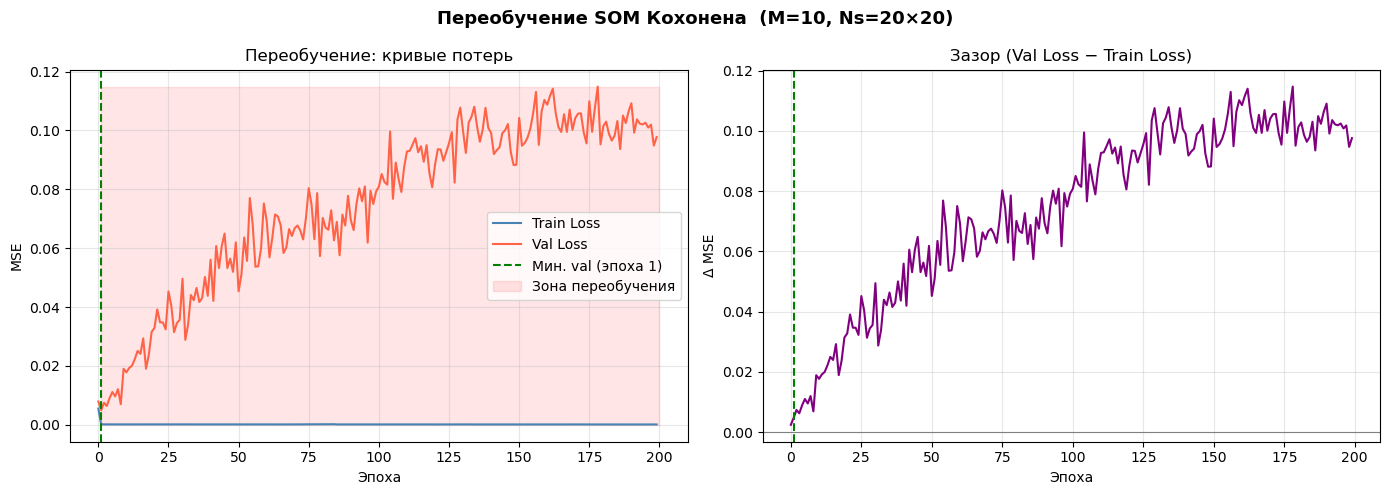


Минимальный val_loss на эпохе 1: 0.00491
Финальный train_loss: 0.00011  |  Финальный val_loss: 0.09774
Зазор переобучения:  0.09763


In [20]:
M_of   = 10    # Маленькое окно
Ns_of  = 20    # Большая карта SOM (20×20 = 400 нейронов)
EPC_OF = 200   # Много эпох без ранней остановки

print(f'Параметры переобучения: M={M_of}, Ns={Ns_of}×{Ns_of}, epochs={EPC_OF}')

X_of, y_of = build_dataset(data_scaled, M_of, D, L)
sp_of = int(len(X_of) * 0.8)
X_tr_of, X_te_of = X_of[:sp_of], X_of[sp_of:]
y_tr_of, y_te_of = y_of[:sp_of], y_of[sp_of:]

# Большая SOM
som_of = SelfOrganizingMap(Ns_of, Ns_of, X_tr_of.shape[1],
                           eta_0=ETA_0, sigma_0=None)
som_of.fit(X_tr_of, n_epochs=150, verbose=False)
print('✓ SOM для переобучения обучена')

X_tr_of_enc = encode_with_som(som_of, X_tr_of)
X_te_of_enc = encode_with_som(som_of, X_te_of)

# Большой регрессор, без EarlyStopping
with tf.device('/GPU:0' if gpus else '/CPU:0'):
    reg_of = build_regressor(X_tr_of_enc.shape[1], hidden=256)
    hist_of = reg_of.fit(
        X_tr_of_enc, y_tr_of,
        validation_data=(X_te_of_enc, y_te_of),
        epochs=EPC_OF,
        batch_size=BATCH,
        verbose=0
    )

tl_of = hist_of.history['loss']
vl_of = hist_of.history['val_loss']
best_epoch = int(np.argmin(vl_of))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(tl_of, label='Train Loss', color='steelblue')
axes[0].plot(vl_of, label='Val Loss',   color='tomato')
axes[0].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5,
                label=f'Мин. val (эпоха {best_epoch})')
axes[0].fill_betweenx([0, max(vl_of)], best_epoch, EPC_OF,
                      alpha=0.1, color='red', label='Зона переобучения')
axes[0].set_title('Переобучение: кривые потерь')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(alpha=0.3)

gap = np.array(vl_of) - np.array(tl_of)
axes[1].plot(gap, color='purple')
axes[1].axvline(best_epoch, color='green', linestyle='--', linewidth=1.5)
axes[1].axhline(0, color='gray', linewidth=0.8)
axes[1].set_title('Зазор (Val Loss − Train Loss)')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Δ MSE')
axes[1].grid(alpha=0.3)

plt.suptitle(f'Переобучение SOM Кохонена  (M={M_of}, Ns={Ns_of}×{Ns_of})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nМинимальный val_loss на эпохе {best_epoch}: {min(vl_of):.5f}')
print(f'Финальный train_loss: {tl_of[-1]:.5f}  |  Финальный val_loss: {vl_of[-1]:.5f}')
print(f'Зазор переобучения:  {vl_of[-1] - tl_of[-1]:.5f}')

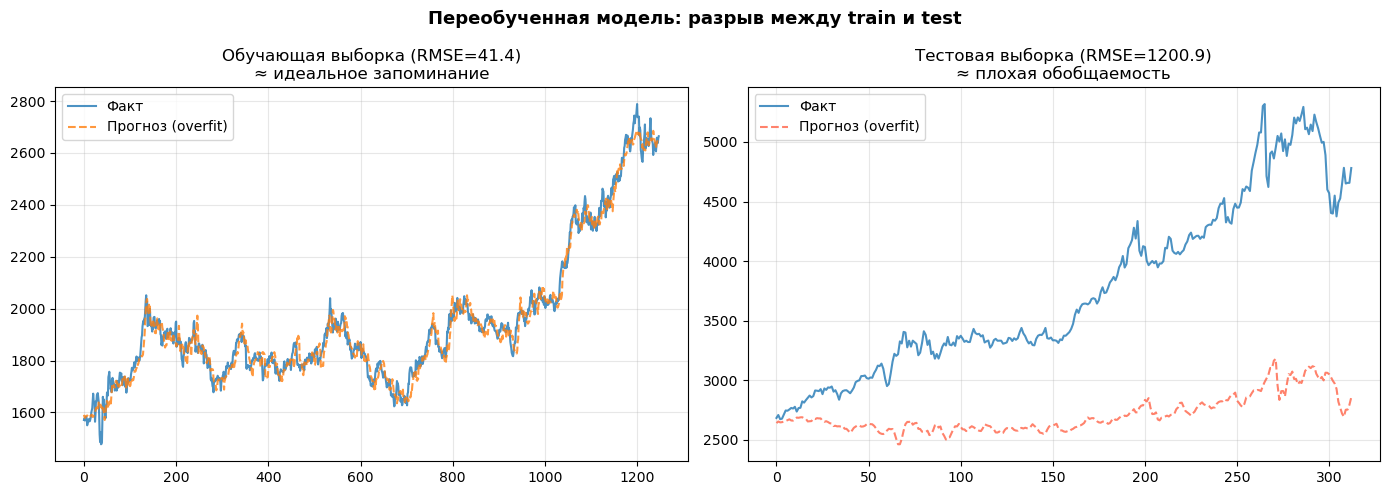

In [21]:
y_pred_of_train = reg_of.predict(X_tr_of_enc, verbose=0).flatten()
y_pred_of_test  = reg_of.predict(X_te_of_enc, verbose=0).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(inverse(y_tr_of), label='Факт', alpha=0.8)
axes[0].plot(inverse(y_pred_of_train), label='Прогноз (overfit)',
             linestyle='--', alpha=0.8)
rmse_tr = np.sqrt(mean_squared_error(inverse(y_tr_of), inverse(y_pred_of_train)))
axes[0].set_title(f'Обучающая выборка (RMSE={rmse_tr:.1f})\n≈ идеальное запоминание')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(inverse(y_te_of), label='Факт', alpha=0.8)
axes[1].plot(inverse(y_pred_of_test), label='Прогноз (overfit)',
             linestyle='--', alpha=0.8, color='tomato')
rmse_te = np.sqrt(mean_squared_error(inverse(y_te_of), inverse(y_pred_of_test)))
axes[1].set_title(f'Тестовая выборка (RMSE={rmse_te:.1f})\n≈ плохая обобщаемость')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Переобученная модель: разрыв между train и test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 14. Выводы

### 14.1 Сеть Кохонена для прогнозирования временных рядов

**Self-Organizing Map** обучается неконтролируемо: нейроны карты специализируются на разных «рыночных режимах» — трендах роста, падения, консолидации. Это позволяет явно интерпретировать, в каком режиме находится рынок в данный момент. Регрессор поверх SOM-кодирования использует эту кластерную информацию для прогноза.

**Ошибка квантования (QE)** — основная метрика качества SOM: показывает среднее расстояние от входных векторов до их BMU. Убывание QE в ходе обучения подтверждает, что карта успешно самоорганизуется.

### 14.2 Влияние параметров на функцию потерь

| Параметр | Наблюдение |
|----------|------------|
| **M** (окно) | Оптимальный M ~20–30: даёт достаточно контекста без избыточного шума |
| **D** (задержки) | D=1 предпочтительно; при D>3 теряется локальная динамика |
| **L** (горизонт) | Потери монотонно растут с L — дальний прогноз принципиально сложнее |
| **Ns** (карта) | Малая карта (Ns=3–5) недообучает, большая (Ns≥16) переобучает |

### 14.3 Переобучение в SOM

Специфика SOM: при большом Ns и малом M карта «запоминает» каждый конкретный паттерн (почти каждый образец получает уникальный BMU). Регрессор легко запоминает маппинг BMU→цена на train, но не обобщается на test.

### 14.4 Сравнение с другими архитектурами

| Метод | Преимущества | Недостатки |
|-------|-------------|------------|
| **SOM Кохонена (данная работа)** | Интерпретируемые кластеры, визуализация рыночных режимов | Двухэтапное обучение, нет сквозного градиента через SOM |
| **Hopfield Network** | Ассоциативная память, связь с энергетическими моделями | Сложнее настроить β |
| **FFNN** | Простота, скорость | Нет структуры памяти |
| **LSTM** | Долгосрочные зависимости | Медленнее, больше параметров |

### 14.5 Возможные улучшения

- **Дифференцируемая SOM** — включить SOM в граф вычислений TF для сквозного обучения
- **Иерархическая SOM** — несколько уровней карт для захвата разных масштабов времени
- **Адаптивный радиус σ(t)** — по графику QE вместо экспоненты
- **Мультиканальный вход** — одновременно золото, серебро, нефть → совместная SOM
- **Временнáя метка как признак** — день недели, месяц, квартал в векторе входа